In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


# Exploratory Data Analysis and Data Understanding

## 1. Choosing the Dataset

In [2]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Dataset Description

The dataset was created by Hadley Wickham in 2008, and the dataset was published on kaggle by Shivam Agrawwal in 2017. This dataset was accessed by searching for the dataset on kaggle.com.

It aligns with the UN SDG 12: Responsible Consumption and Production because by analyzing and modeling the factors that determine diamond prices, this study encourages transparency and enables consumers and businesses to make more informed puschasing and pricing decisions respectively. This contributes to more ethical and responsible production and consumption practices in the jewelry industry.

The attributes of the dataset are listed below:

*   Price: The price of the diamond in US dollars (\$326--\$18,823)
*   carat: Carat weight of the diamond where 1 carat = 0.2 grams (0.2--5.01)

*   cut: Quality of the cut of the diamond (Fair, Good, Very Good, Premium, Ideal)
*   color: The lesser the color, more the light passes through cleanly, leading to a higher price. From J(worst) to D(best)



*   clarity: A measurement of how clear the diamond is. (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
*   x: length in mm (0--10.74)


*   y: width in mm (0--58.9)
*   z: depth in mm (0--31.8)



*   depth : It indicates how deep the diamond is relative to its width.
total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
*   table: The width of the top flat surface of the diamond expressed as a percentage of its widest point or, width of top of diamond relative to widest point (43--95)











### Some potential questions the dataset could help answer



1.   What attributes of diamonds are the significant predictors of market price and how do they rank in terms of influence on price?
2.   How can the physical and qualitative characteristics of a diamond be used to accurately predict it's market price?
3.   How do diamonds with similar carat weights differ in price based on factors such as cut, clarity, color and dimensions?



### Suitability

The dataset chosen is suitable for this study as it contains information that is highly relevant to the research question, containing key physical and qualitative attributes that determine a diamond's pricing. It is sufficiently complete with a large number of entries. While there are no null values in major variables, there are some entries with invalid dimension values that require cleaning. Observing the non linear trend of increase of price and it's wide range, EDA and pre-processing are required to search for potential outliers as well.

## 2. Exploratory Data Analysis (EDA)

In [3]:
# Checking for the dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [4]:
# Dropping the unnamed column
df.drop(columns=['Unnamed: 0'],inplace= True)

Checking for null values in the dataset

In [5]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [6]:
# Searching for duplicate values
df.duplicated().sum()

np.int64(146)

In [7]:
# Dropping the duplicated values
df.drop_duplicates()

#Resseting the index
df.reset_index(drop=True, inplace=True)
print(f"Final count: {len(df)} rows")

Final count: 53940 rows


Checking for illogical values in numerical columns

In [8]:
(df[['x','y','z','depth','table','carat','price']]== 0).sum()

,0
x,8
y,7
z,20
depth,0
table,0
carat,0
price,0


Handling the illogical values

In [9]:
# Removing rows where x, y, or z are 0
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

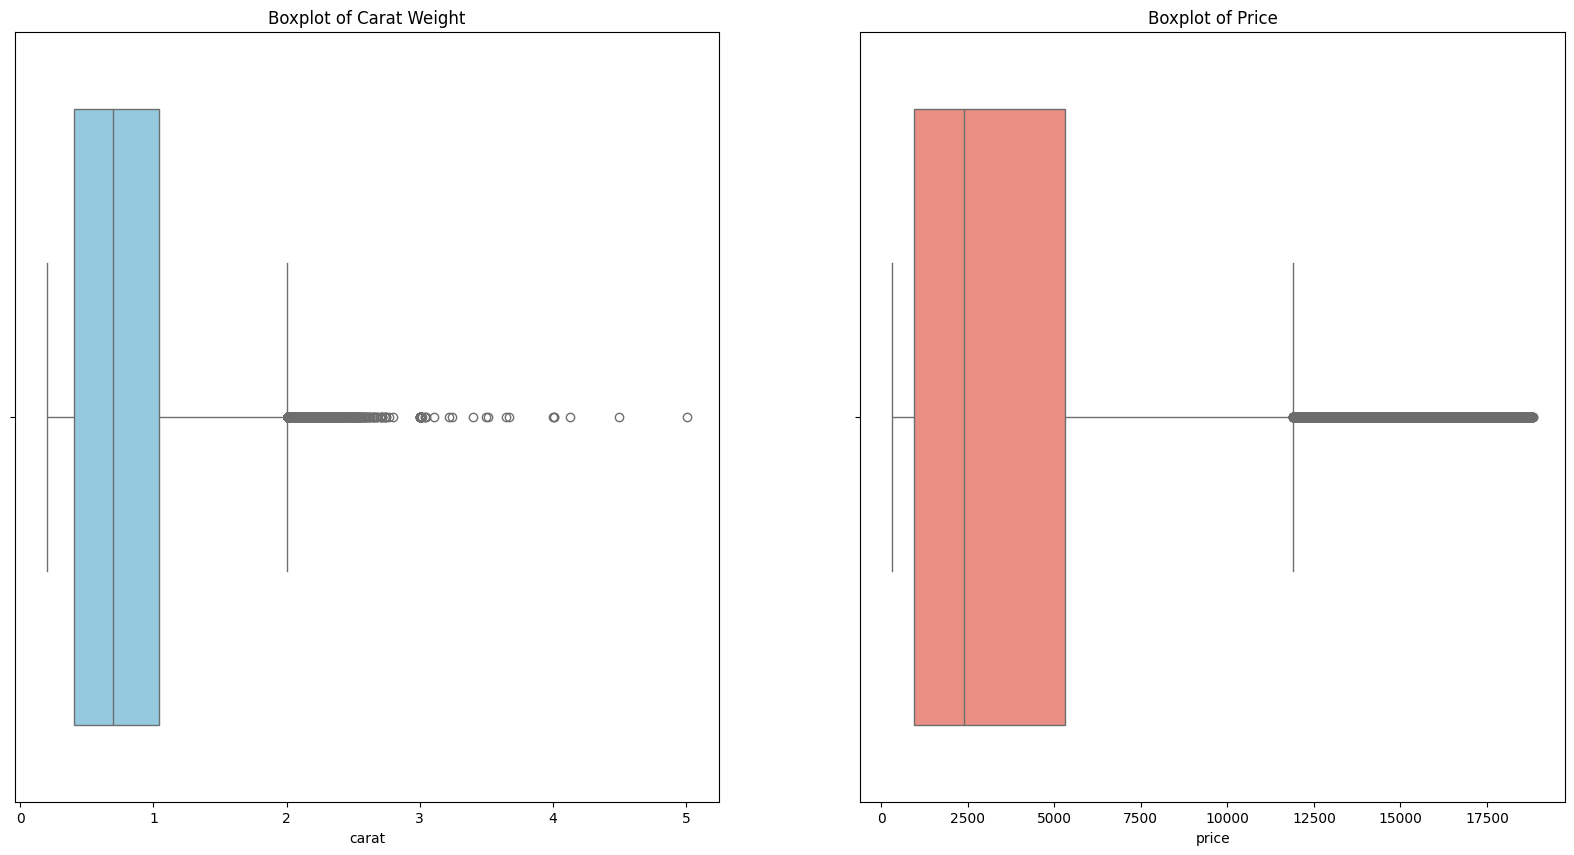

In [10]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Boxplot for Carat
sns.boxplot(ax=axes[0], x=df['carat'], color='skyblue')
axes[0].set_title('Boxplot of Carat Weight')

# Boxplot for Price
sns.boxplot(ax=axes[1], x=df['price'], color='salmon')
axes[1].set_title('Boxplot of Price')

plt.show()

We can observe that because most diamonds are in the carat range between about 0.4 to 1.1 and in the price range between 1500 to 5350 USD and because of that, we can observe quite a large number of outliers as well. This does not mean that they are invalid data, as rare, high carat and high price diamonds can be a real possibility.

In [11]:
# Function to find outliers based on IQR
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    outliers = df[(df[column] > upper_bound) | (df[column] < lower_bound)]
    return outliers, upper_bound

# Checking outliers for 'carat'
carat_outliers, limit = find_outliers_iqr(df, 'carat')
print(f"Anything above {limit:.2f} carats is technically an outlier.")
print(f"Number of carat outliers: {len(carat_outliers)}")

# Checkiing outliers for 'price'
price_outliers, limit = find_outliers_iqr(df, 'price')
print(f"Anything above {limit:.2f} carats is technically an outlier.")
print(f"Number of carat outliers: {len(price_outliers)}")

Anything above 2.00 carats is technically an outlier.
Number of carat outliers: 1883
Anything above 11884.62 carats is technically an outlier.
Number of carat outliers: 3532


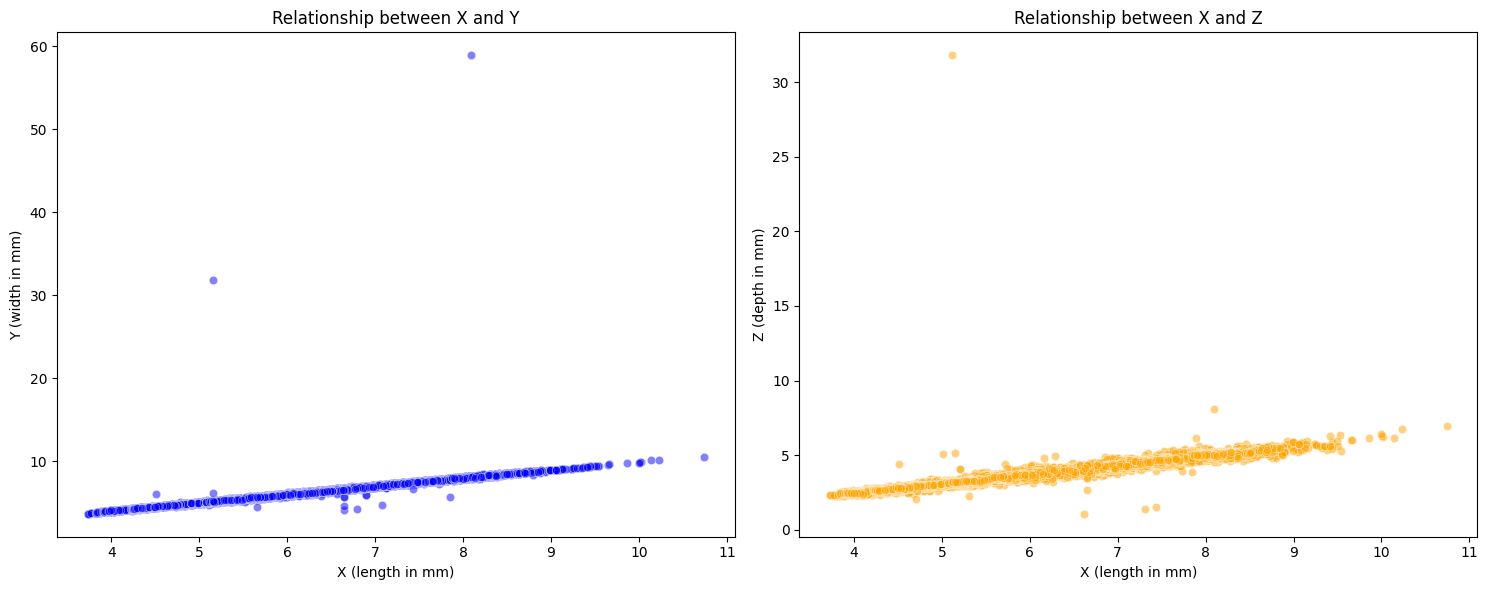

In [12]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Relationship between X and Y
sns.scatterplot(data=df, x='x', y='y', ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title('Relationship between X and Y')
axes[0].set_xlabel('X (length in mm)')
axes[0].set_ylabel('Y (width in mm)')

# Subplot 2: Relationship between X and Z
sns.scatterplot(data=df, x='x', y='z', ax=axes[1], color='orange', alpha=0.5)
axes[1].set_title('Relationship between X and Z')
axes[1].set_xlabel('X (length in mm)')
axes[1].set_ylabel('Z (depth in mm)')

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

We can see that there are two instances where there are abnormal values of y as compared to x, and also and instance where the value of z is abnormal. They are outliers that are physically impossible.

In [13]:
# Removing entries having

# Most diamonds have an x/y ratio between 0.8 and 1.2
# Most diamonds have a z/x ratio between 0.5 and 0.7
print(f"Rows before ratio filtering: {len(df)}")

df = df[
    # Rule 1: x and y should be somewhat similar (removes 'sticks')
    (df['x'] / df['y'] > 0.8) & (df['x'] / df['y'] < 1.2) &

    # Rule 2: z should be about 50-70% of x (removes 'pancakes' and 'needles')
    (df['z'] / df['x'] > 0.5) & (df['z'] / df['x'] < 0.7)
]

print(f"Rows after ratio filtering: {len(df)}")

Rows before ratio filtering: 53920
Rows after ratio filtering: 53885


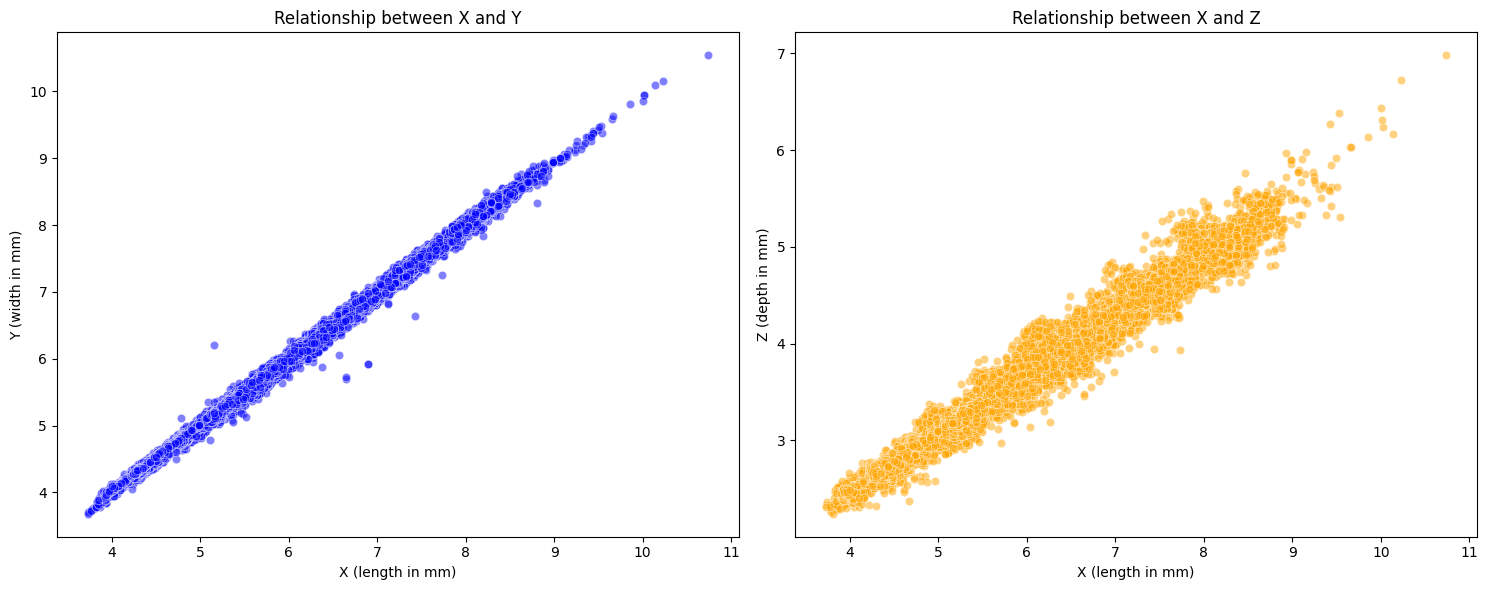

In [14]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Relationship between X and Y
sns.scatterplot(data=df, x='x', y='y', ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title('Relationship between X and Y')
axes[0].set_xlabel('X (length in mm)')
axes[0].set_ylabel('Y (width in mm)')

# Subplot 2: Relationship between X and Z
sns.scatterplot(data=df, x='x', y='z', ax=axes[1], color='orange', alpha=0.5)
axes[1].set_title('Relationship between X and Z')
axes[1].set_xlabel('X (length in mm)')
axes[1].set_ylabel('Z (depth in mm)')

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

In [15]:
#Summary statistics

df.describe()

,carat,depth,table,price,x,y,z
count,53885.000000,53885.000000,53885.000000,53885.000000,53885.000000,53885.000000,53885.000000
mean,0.797510,61.746211,57.456524,3930.414772,5.731336,5.733398,3.539211
std,0.473663,1.418352,2.231841,3986.982935,1.119438,1.111322,0.691179
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,2.240000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.030000
max,5.010000,70.800000,95.000000,18823.000000,10.740000,10.540000,6.980000


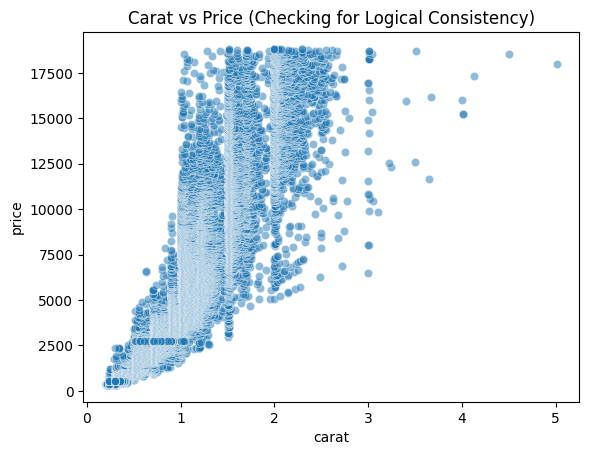

In [16]:
# Scatter plot to see if price and carat align logically
sns.scatterplot(data=df, x='carat', y='price', alpha=0.5)
plt.title('Carat vs Price (Checking for Logical Consistency)')
plt.show()

**Interpretation**

We can observe that as the carat increases the overall price range also seems to move higher. But we can also observe that carat value as in the lower range of 1, also has many diamonds that rival the price of higher carat diamonds such as 2,3,4 and 5. This suggests that although carat plays a big role in determining diamond prices, it is not the only determining factor, as a 1 carat diamond might have prices from 2500 USD to above 17,500 USD.

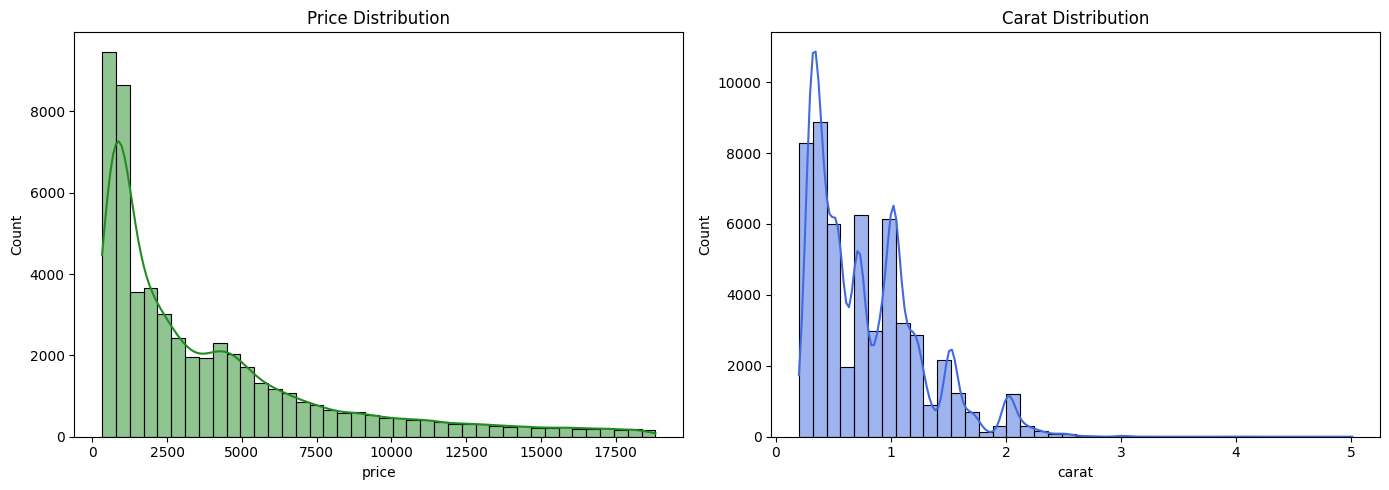

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plotting histogram of price
sns.histplot(df['price'], bins=40, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Price Distribution')

# Plotting the histogram of carat
sns.histplot(df['carat'], bins=40, kde=True, ax=axes[1], color='royalblue')
axes[1].set_title('Carat Distribution')

plt.tight_layout()
plt.show()

From the above histograms of price and carat, we can see that both price and carat distributions are right-skewed. We can see that most market prices of diamonds are between 300 and 2500 USD whereas most carat weights of diamonds are between 0.3 and 1.1.

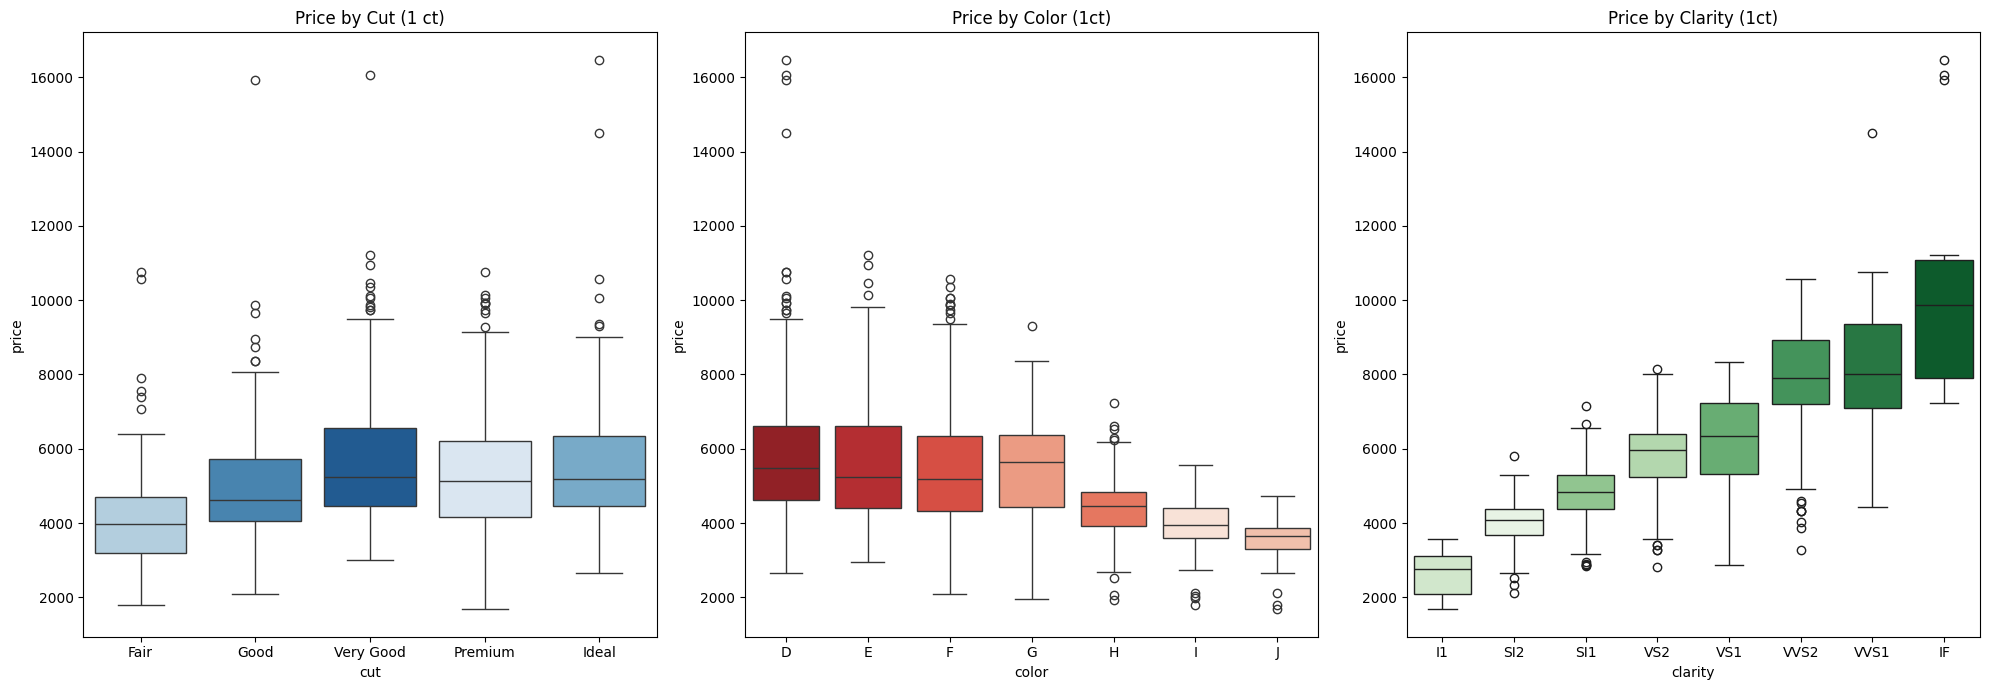

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the "Sweet Spot" range
df_plot = df[df['carat']== 1.0].copy()

# Define the exact order for the X-axis
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Setup the figure
plt.figure(figsize=(20, 7))

# Plot 1: Cut
plt.subplot(1, 3, 1)
sns.boxplot(data=df_plot, x='cut', y='price', order=cut_order,
            hue='cut', palette='Blues', legend=False)
plt.title('Price by Cut (1 ct)')

# Plot 2: Color ---
plt.subplot(1, 3, 2)
sns.boxplot(data=df_plot, x='color', y='price', order=color_order,
            hue='color', palette='Reds', legend=False)
plt.title('Price by Color (1ct)')

# Plot 3: Clarity
plt.subplot(1, 3, 3)
sns.boxplot(data=df_plot, x='clarity', y='price', order=clarity_order,
            hue='clarity', palette='Greens', legend=False)
plt.title('Price by Clarity (1ct)')

plt.tight_layout()
plt.show()

When holding the carat value exactly at 1 ct, we can clearly observe the significance of the categorical columns in determining the price of a diamond, While carat establishes the floor price we can see that the median price typically tends to increase as the category values get better. Clarity shows a consistent upward trend in median prices as the clarity grade increases from I1 to IF.

Furthermore, the presence of significant high-value outliers—especially within the D-color, Ideal-cut, and IF-clarity categories illustrates the 'Luxury Combination' effect where the combinations of the best of all three categorical values creates an exponential diamond price.

This confirms that the effect from these qualitative values is not just added to the price of diamonds but in fact multiplied when combined.

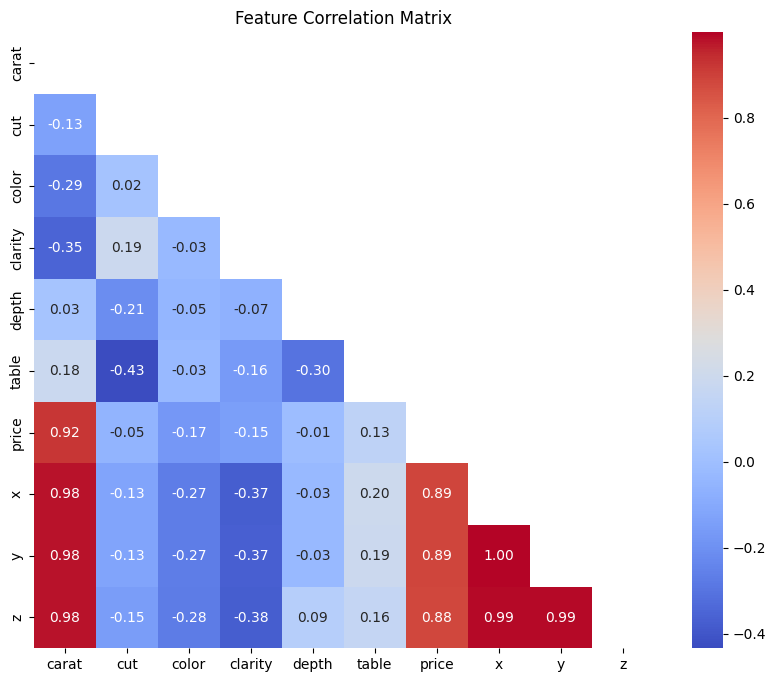

In [19]:
#Mapping the categories to numerical ranks
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

#Creating the encoded columns
df['cut'] = df['cut'].map(cut_map)
df['color'] = df['color'].map(color_map)
df['clarity'] = df['clarity'].map(clarity_map)

#Generate the Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

We can observe from the heatmap that carat is almost perfectly correlated with the physical dimensions of the diamond (x, y, z), meaning that when the diamond gets heavier,it's physical dimensions grow at the exact same rate. Because these four variables essentially tell the same story, keeping all of them would be redundant and would confuse the model. We can also observe that carat has the highest correlation with price so we simplify our model by dropping x,y and z.

It should also be noted that the correlation matrix only shows individual linear relationships between each feature and price and does not capture the combined effects of categorical features such as cut, color and clarity when considered together.

# Building a Neural Network Model for Regression

In [20]:
# Selecting X and Y
X = df.drop(columns=['price'])

# Using Log Transform on the Target to handle luxury price spikes
y = df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the inputs (MLP is very sensitive to feature scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Initialize the Neural Network
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train the model
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [22]:
# Predictions (In Log Scale)
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred= mlp.predict(X_test_scaled)


# Function to Calculate All Metrics
def calculate_metrics(actual, pred):
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return mse, rmse, mae, r2

# Get Metrics
train_mse, train_rmse, train_mae, train_r2 = calculate_metrics(y_train, y_train_pred)
test_mse, test_rmse, test_mae, test_r2 = calculate_metrics(y_test, y_test_pred)

# Clean Report Output
print("--- Neural Network (MLP) Final Performance ---")
print(f"{'Metric':<10} | {'Training Set':<15} | {'Test Set':<15}")
print("-" * 45)
print(f"{'MSE':<10} | {train_mse:<15,.2f} | {test_mse:<15,.2f}")
print(f"{'RMSE':<10} | ${train_rmse:<14,.2f} | ${test_rmse:<14,.2f}")
print(f"{'MAE':<10} | ${train_mae:<14,.2f} | ${test_mae:<14,.2f}")
print(f"{'R-Squared':<10} | {train_r2:<15.4f} | {test_r2:<15.4f}")

--- Neural Network (MLP) Final Performance ---
Metric     | Training Set    | Test Set       
---------------------------------------------
MSE        | 305,391.64      | 296,973.98     
RMSE       | $552.62         | $544.95        
MAE        | $303.72         | $297.12        
R-Squared  | 0.9809          | 0.9807         


# Building Primary machine learning models (Two Classical ML models):

## Linear Regression

In [23]:
# Train
baseline_lr_model = LinearRegression()
baseline_lr_model.fit(X_train_scaled, y_train)

#Get Predictions
y_train_pred_lr = baseline_lr_model.predict(X_train_scaled)
y_test_pred_lr = baseline_lr_model.predict(X_test_scaled)

#Use the function for Training Set
train_mse_lr, train_rmse_lr, train_mae_lr, train_r2_lr = calculate_metrics(y_train, y_train_pred_lr)

#Use the function for Test Set
test_mse_lr, test_rmse_lr, test_mae_lr, test_r2_lr = calculate_metrics(y_test, y_test_pred_lr)

#Print the Report
print("--- Baseline Linear Regression Final Performance ---")
print(f"{'Metric':<10} | {'Training Set':<15} | {'Test Set':<15}")
print("-" * 45)
print(f"{'MSE':<10} | {train_mse_lr:<15,.2f} | {test_mse_lr:<15,.2f}")
print(f"{'RMSE':<10} | ${train_rmse_lr:<14,.2f} | ${test_rmse_lr:<14,.2f}")
print(f"{'MAE':<10} | ${train_mae_lr:<14,.2f} | ${test_mae_lr:<14,.2f}")
print(f"{'R-Squared':<10} | {train_r2_lr:<15.4f} | {test_r2_lr:<15.4f}")

--- Baseline Linear Regression Final Performance ---
Metric     | Training Set    | Test Set       
---------------------------------------------
MSE        | 1,445,103.91    | 1,451,456.50   
RMSE       | $1,202.12       | $1,204.76      
MAE        | $798.36         | $784.91        
R-Squared  | 0.9098          | 0.9056         


## Random Forest

In [24]:
#Initialize
rf_baseline_model = RandomForestRegressor(n_estimators=100, random_state=42)

#Train on standard dollar values (Random Forest handles outliers well!)
rf_baseline_model.fit(X_train_scaled, y_train)

#Get Predictions for both Train and Test sets
y_train_pred_rf = rf_baseline_model.predict(X_train_scaled)
y_test_pred_rf = rf_baseline_model.predict(X_test_scaled)

#Use the function for Training Set
train_mse_rf, train_rmse_rf, train_mae_rf, train_r2_rf = calculate_metrics(y_train, y_train_pred_rf)

#Use the function for Test Set
test_mse_rf, test_rmse_rf, test_mae_rf, test_r2_rf = calculate_metrics(y_test, y_test_pred_rf)

#Print the Final Report
print("--- Baseline Random Forest Final Performance ---")
print(f"{'Metric':<10} | {'Training Set':<15} | {'Test Set':<15}")
print("-" * 45)
print(f"{'MSE':<10} | {train_mse_rf:<15,.2f} | {test_mse_rf:<15,.2f}")
print(f"{'RMSE':<10} | ${train_rmse_rf:<14,.2f} | ${test_rmse_rf:<14,.2f}")
print(f"{'MAE':<10} | ${train_mae_rf:<14,.2f} | ${test_mae_rf:<14,.2f}")
print(f"{'R-Squared':<10} | {train_r2_rf:<15.4f} | {test_r2_rf:<15.4f}")

--- Baseline Random Forest Final Performance ---
Metric     | Training Set    | Test Set       
---------------------------------------------
MSE        | 40,893.81       | 277,732.98     
RMSE       | $202.22         | $527.00        
MAE        | $99.60          | $257.33        
R-Squared  | 0.9974          | 0.9819         


## 4. Hyperparameter Optimization with Cross-Validation

In [25]:
# MODEL 1: Ridge Regression Optimization
ridge = Ridge()
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

# MODEL 2: Random Forest Optimization
# We use a smaller grid to save time, but we can expand it
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

# Summarize and Report
print("--- Hyperparameter Optimization Results ---")
print(f"Ridge Best Params: {ridge_grid.best_params_}")
print(f"Ridge Best CV Score (R2): {ridge_grid.best_score_:.4f}")
print("-" * 30)
print(f"RF Best Params: {rf_grid.best_params_}")
print(f"RF Best CV Score (R2): {rf_grid.best_score_:.4f}")

--- Hyperparameter Optimization Results ---
Ridge Best Params: {'alpha': 1.0}
Ridge Best CV Score (R2): 0.9096
------------------------------
RF Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
RF Best CV Score (R2): 0.9810


# Feature Selection

In [26]:
from sklearn.feature_selection import SelectFromModel

# Feature Selection for Ridge (Linear Model)
selector_ridge = SelectFromModel(ridge_grid.best_estimator_, threshold="median", prefit=True)
selected_features_ridge = X.columns[selector_ridge.get_support()]

# Feature Selection for Random Forest
selector_rf = SelectFromModel(rf_grid.best_estimator_, threshold="median", prefit=True)
selected_features_rf = X.columns[selector_rf.get_support()]

print(f"Ridge Selected Features: {list(selected_features_ridge)}")
print(f"RF Selected Features: {list(selected_features_rf)}")

Ridge Selected Features: ['carat', 'clarity', 'x', 'y', 'z']
RF Selected Features: ['carat', 'color', 'clarity', 'y', 'z']


# Final Models and comparative analysis

In [27]:
# Prepare Data for Final Ridge Model
# Filter the scaled data using the Ridge-specific selected features
X_train_ridge = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features_ridge]
X_test_ridge = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features_ridge]

# Final Ridge Regression (using alpha: 1.0)
final_lr = Ridge(alpha=1.0)
final_lr.fit(X_train_ridge, y_train)
y_pred_lr_final = final_lr.predict(X_test_ridge)


# Prepare Data for Final Random Forest Model
# Filter the scaled data using the RF-specific selected features
X_train_rf = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features_rf]
X_test_rf = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features_rf]

# Final Random Forest (using your optimized params)
final_rf = RandomForestRegressor(
    max_depth=20,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)
final_rf.fit(X_train_rf, y_train)
y_pred_rf_final = final_rf.predict(X_test_rf)

In [28]:
import pandas as pd

# Calculate final metrics (capturing the first return value as MAE)
final_mae_lr, final_rmse_lr, _, final_r2_lr = calculate_metrics(y_test, y_pred_lr_final)
final_mae_rf, final_rmse_rf, _, final_r2_rf = calculate_metrics(y_test, y_pred_rf_final)

# Extract CV scores directly from the grid search objects
cv_score_lr = ridge_grid.best_score_
cv_score_rf = rf_grid.best_score_

# Create the Structured Table with MAE included
results_data = {
    'Model': ['Linear Regression (Ridge)', 'Random Forest'],
    'Features Used': [
        f'Selected ({len(selected_features_ridge)})',
        f'Selected ({len(selected_features_rf)})'
    ],
    'CV Score (R2)': [f"{cv_score_lr:.4f}", f"{cv_score_rf:.4f}"],
    'Test MAE': [f"${final_mae_lr:,.2f}", f"${final_mae_rf:,.2f}"], # Added MAE
    'Test RMSE': [f"${final_rmse_lr:,.2f}", f"${final_rmse_rf:,.2f}"],
    'Test R-squared': [f"{final_r2_lr:.4f}", f"{final_r2_rf:.4f}"]
}

comparison_table = pd.DataFrame(results_data)

# Print the final table
print("Table 2: Comparison of Final Regression Models")
print("-" * 100)
print(comparison_table.to_string(index=False))
print("-" * 100)

Table 2: Comparison of Final Regression Models
----------------------------------------------------------------------------------------------------
                    Model Features Used CV Score (R2)      Test MAE Test RMSE Test R-squared
Linear Regression (Ridge)  Selected (5)        0.9096 $1,757,718.68 $1,325.79         0.8857
            Random Forest  Selected (5)        0.9810   $304,525.19   $551.84         0.9802
----------------------------------------------------------------------------------------------------


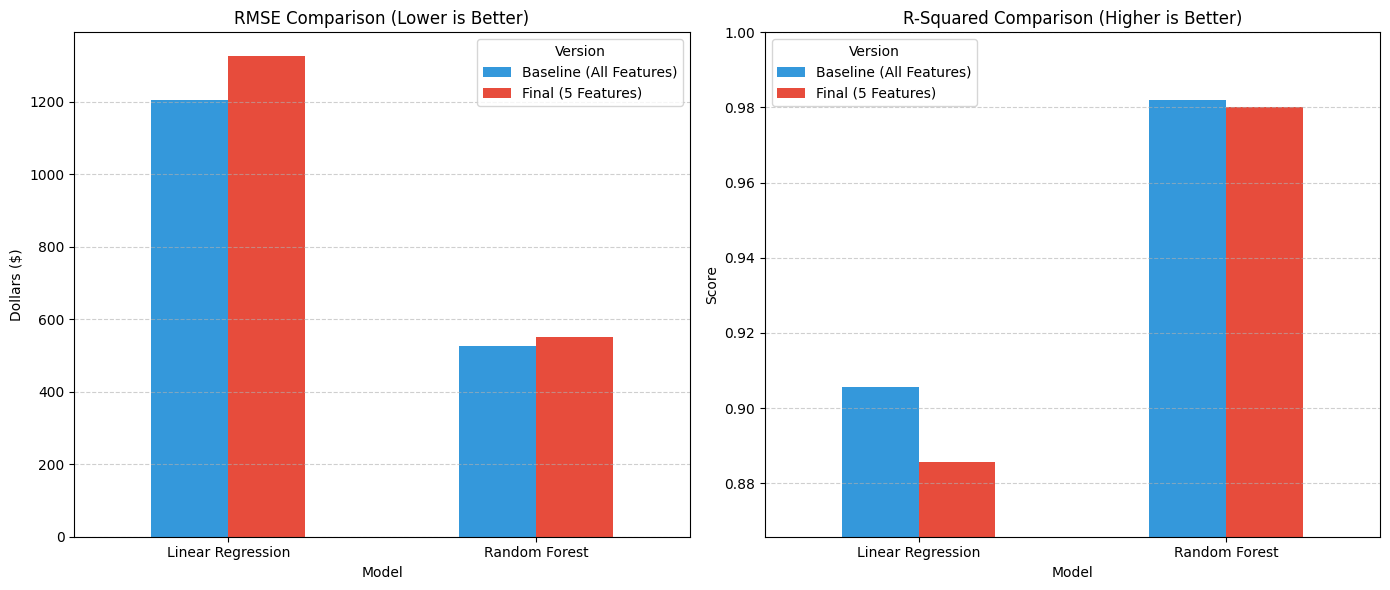

--- Final Comparison DataFrame ---


,Model,Version,RMSE,R2
0,Linear Regression,Baseline (All Features),1204.764083,0.905647
1,Random Forest,Baseline (All Features),527.003777,0.981946
2,Linear Regression,Final (5 Features),1325.789833,0.885738
3,Random Forest,Final (5 Features),551.838012,0.980204


In [29]:
# Create a structured DataFrame using your variables from previous steps
comparison_data = {
    'Model': ['Linear Regression', 'Random Forest', 'Linear Regression', 'Random Forest'],
    'Version': ['Baseline (All Features)', 'Baseline (All Features)', 'Final (5 Features)', 'Final (5 Features)'],
    'RMSE': [
        test_rmse_lr,  # From Task 3 baseline
        test_rmse_rf,  # From Task 3 baseline
        final_rmse_lr,     # From Task 6 final
        final_rmse_rf      # From Task 6 final
    ],
    'R2': [
        test_r2_lr,    # From Task 3 baseline
        test_r2_rf,    # From Task 3 baseline
        final_r2_lr,       # From Task 6 final
        final_r2_rf        # From Task 6 final
    ]
}

df_comp = pd.DataFrame(comparison_data)

# Pivot the data for grouped bar plotting
rmse_pivot = df_comp.pivot(index='Model', columns='Version', values='RMSE')
r2_pivot = df_comp.pivot(index='Model', columns='Version', values='R2')

# Create the Bar Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# RMSE Plot (Lower is Better)
# We use the index of rmse_pivot to ensure labels match correctly
rmse_pivot.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'], rot=0)
ax1.set_title('RMSE Comparison (Lower is Better)')
ax1.set_ylabel('Dollars ($)')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# R2 Plot (Higher is Better)
r2_pivot.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'], rot=0)
ax2.set_title('R-Squared Comparison (Higher is Better)')
ax2.set_ylabel('Score')
# Dynamically set ylim to just below the minimum R2 to show detail
ax2.set_ylim(df_comp['R2'].min() - 0.02, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Display the DataFrame
print("--- Final Comparison DataFrame ---")
display(df_comp)